In [1]:
import sys
from utils import * 


In [2]:
csv_file = "train_transaction22.csv"
DATASET_NAME = csv_file.replace(".csv", "")
TARGET_COL = "isFraud"
DROP_COLS = ['Unnamed: 0', 'TransactionID', 'TransactionDT', 'ProductCD', 'card4', 'card6', 'P_emaildomain']

df = pd.read_csv(csv_file)
# df

isFraud
0    569877
1     20663
Name: count, dtype: int64


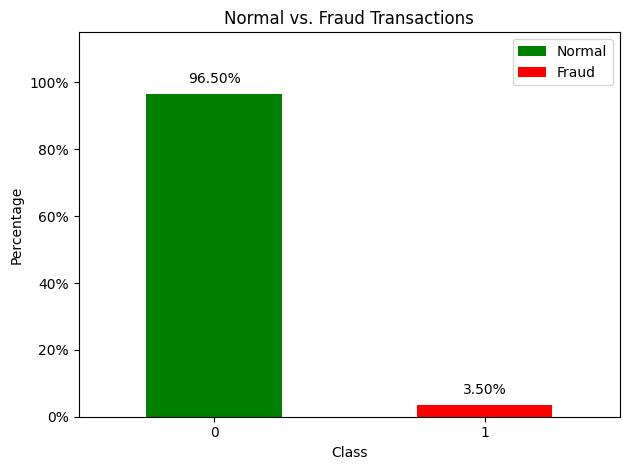

In [3]:
plot_class_distribution(df, target_col=TARGET_COL)


In [4]:
# Data preprocessing
X_train, X_test, y_train, y_test = anomaly_preprocess(df=df, target_col=TARGET_COL, drop_cols=DROP_COLS)


In [5]:
# ------------------ Autoencoder Feature Extraction ------------------
X_train, X_test = apply_autoencoder(X_train, X_test)

print("Encoded train shape:", X_train.shape)
print("Encoded test shape:", X_test.shape)


Epoch 1/10
8621/8621 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - loss: -2.3004
Epoch 2/10
8621/8621 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: -12.1845
Epoch 3/10
8621/8621 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - loss: -21.9990
Epoch 4/10
8621/8621 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: -31.7721
Epoch 5/10
8621/8621 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: -41.6730
Epoch 6/10
8621/8621 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - loss: -51.3272
Epoch 7/10
8621/8621 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - loss: -61.3751
Epoch 8/10
8621/8621 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: -71.2237
Epoch 9/10
8621/8621 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: -81.1202
Epoch 10/10
8621/8621 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - loss: -91.0756
8621/8621 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step
3691/3691 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
Encoded train shape: (275857, 8)
Encoded test shape: (118108, 8)


In [6]:
import joblib

joblib.dump((DATASET_NAME, X_train, X_test, y_train, y_test), "IEEE_data.pkl")

DATASET_NAME, X_train, X_test, y_train, y_test = joblib.load("IEEE_data.pkl")
